# Frost Days — Exploration des données

Objectif de ce notebook :
1. Comprendre la structure réelle des fichiers météo (`RR-T-Vent`) téléchargés
2. Vérifier la qualité des données (valeurs manquantes, codes qualité)
3. Appliquer la règle des 35% de valeurs manquantes pour identifier les stations à exclure
4. Explorer le référentiel des communes et les coordonnées manquantes
5. Vérifier la cohérence du calcul des jours de gel sur un cas connu
6. Tester le matching commune → station la plus proche (Haversine)

Pré-requis : avoir déjà exécuté `python src/download_data.py --depts <vos_depts>`.


In [1]:
import sys
import os
import glob

sys.path.insert(0, os.path.abspath(".."))
import config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Quels fichiers météo avons-nous localement ?

In [2]:
meteo_files = sorted(glob.glob(os.path.join(config.METEO_RAW_DIR, "*RR-T-Vent*.csv.gz")))
print(f"{len(meteo_files)} fichier(s) météo RR-T-Vent trouvé(s) :")
for f in meteo_files:
    size_mo = os.path.getsize(f) / 1e6
    print(f"  - {os.path.basename(f)}  ({size_mo:.1f} Mo)")


103 fichier(s) météo RR-T-Vent trouvé(s) :
  - Q_01_previous-1950-2024_RR-T-Vent.csv.gz  (9.3 Mo)
  - Q_02_previous-1950-2024_RR-T-Vent.csv.gz  (11.3 Mo)
  - Q_03_previous-1950-2024_RR-T-Vent.csv.gz  (13.8 Mo)
  - Q_04_previous-1950-2024_RR-T-Vent.csv.gz  (9.6 Mo)
  - Q_05_previous-1950-2024_RR-T-Vent.csv.gz  (13.3 Mo)
  - Q_06_previous-1950-2024_RR-T-Vent.csv.gz  (19.5 Mo)
  - Q_07_previous-1950-2024_RR-T-Vent.csv.gz  (17.0 Mo)
  - Q_08_previous-1950-2024_RR-T-Vent.csv.gz  (8.4 Mo)
  - Q_09_previous-1950-2024_RR-T-Vent.csv.gz  (10.0 Mo)
  - Q_10_previous-1950-2024_RR-T-Vent.csv.gz  (10.1 Mo)
  - Q_11_previous-1950-2024_RR-T-Vent.csv.gz  (14.7 Mo)
  - Q_12_previous-1950-2024_RR-T-Vent.csv.gz  (11.6 Mo)
  - Q_13_previous-1950-2024_RR-T-Vent.csv.gz  (15.3 Mo)
  - Q_14_previous-1950-2024_RR-T-Vent.csv.gz  (9.8 Mo)
  - Q_15_previous-1950-2024_RR-T-Vent.csv.gz  (11.2 Mo)
  - Q_16_previous-1950-2024_RR-T-Vent.csv.gz  (10.4 Mo)
  - Q_17_previous-1950-2024_RR-T-Vent.csv.gz  (10.9 Mo)
  - Q_18_

## 2. Structure réelle d'un fichier

On charge un seul département pour inspecter les colonnes effectivement présentes
(elles peuvent légèrement varier selon les versions du dataset), et en particulier
vérifier la présence des codes qualité associés à `TN`.


In [3]:
assert meteo_files, "Aucun fichier météo trouvé. Lancez d'abord src/download_data.py."

sample_path = meteo_files[0]
print(f"Fichier d'exemple : {os.path.basename(sample_path)}\n")

# Le séparateur est ';' (confirmé par la documentation Météo-France)
df_sample = pd.read_csv(
    sample_path, sep=";", compression="gzip", nrows=5,
    dtype={"NUM_POSTE": str, "AAAAMMJJ": str},
)
print("Colonnes présentes :")
print(list(df_sample.columns))
df_sample.head()


Fichier d'exemple : Q_01_previous-1950-2024_RR-T-Vent.csv.gz

Colonnes présentes :
['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR', 'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM', 'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50', 'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY', 'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI', 'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S', 'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR', 'STATUS_FXI3S', 'STATUS_DXI3S']


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,HTN,QHTN,TX,QTX,HTX,QHTX,TM,QTM,TNTXM,QTNTXM,TAMPLI,QTAMPLI,TNSOL,QTNSOL,TN50,...,QDXY,HXY,QHXY,FXI,QFXI,DXI,QDXI,HXI,QHXI,FXI2,QFXI2,DXI2,QDXI2,HXI2,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,STATUS_FXI3S,STATUS_DXI3S
0,01010001,ANGLEFORT,45.913667,5.809833,275,19500101,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01010001,ANGLEFORT,45.913667,5.809833,275,19500102,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01010001,ANGLEFORT,45.913667,5.809833,275,19500103,13.8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01010001,ANGLEFORT,45.913667,5.809833,275,19500104,5.4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01010001,ANGLEFORT,45.913667,5.809833,275,19500105,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Point d'attention** : la documentation officielle indique qu'un code qualité
(`QTN`, `QTX`, etc.) accompagne chaque mesure. On vérifie ci-dessus s'il est présent
dans le fichier réellement téléchargé — certains exports n'incluent que les valeurs
sans les codes qualité. Si `QTN` est absent, on travaillera uniquement sur la
présence/absence de `TN` (valeur manquante = NaN) sans filtrer sur la qualité.


In [4]:
has_qtn = "QTN" in df_sample.columns
print(f"Colonne QTN (code qualité de TN) présente : {has_qtn}")
if has_qtn:
    print("\nValeurs prises par QTN sur l'échantillon :")
    print(df_sample["QTN"].value_counts(dropna=False))


Colonne QTN (code qualité de TN) présente : True

Valeurs prises par QTN sur l'échantillon :
QTN
NaN    5
Name: count, dtype: int64


## 3. Chargement complet d'un département sur la période 2014-2023

In [5]:
USECOLS = ["NUM_POSTE", "NOM_USUEL", "LAT", "LON", "ALTI", "AAAAMMJJ", "TN"]
# on ajoute QTN seulement s'il existe, pour ne pas faire planter read_csv
header_cols = pd.read_csv(sample_path, sep=";", compression="gzip", nrows=0).columns
if "QTN" in header_cols:
    USECOLS.append("QTN")

df = pd.read_csv(
    sample_path, sep=";", compression="gzip",
    usecols=USECOLS,
    dtype={"NUM_POSTE": str},
)
df["AAAAMMJJ"] = pd.to_datetime(df["AAAAMMJJ"], format="%Y%m%d")

print(f"{len(df):,} lignes chargées au total pour ce département.")
print(f"Plage de dates disponible : {df['AAAAMMJJ'].min().date()} -> {df['AAAAMMJJ'].max().date()}")

# Filtre sur la période d'intérêt du défi
start = pd.Timestamp(config.DEFAULT_START_YEAR, 1, 1)
end = pd.Timestamp(config.DEFAULT_END_YEAR, 12, 31)
df_period = df[(df["AAAAMMJJ"] >= start) & (df["AAAAMMJJ"] <= end)].copy()
print(f"{len(df_period):,} lignes sur la période {config.DEFAULT_START_YEAR}-{config.DEFAULT_END_YEAR}.")


967,830 lignes chargées au total pour ce département.
Plage de dates disponible : 1950-01-01 -> 2024-12-31
122,738 lignes sur la période 2014-2023.


## 4. Taux de valeurs manquantes par station

Règle du défi : si une station a plus de 35% de valeurs manquantes sur la période
demandée, on l'exclut du calcul. On calcule ici ce taux pour chaque station du
département chargé.

Une "valeur manquante" est un jour où la station existait dans la période (en théorie
un relevé quotidien) mais où `TN` est NaN. Pour estimer le nombre de jours attendus
par station, on se base sur l'intervalle [date min, date max] de présence de cette
station dans le fichier (et pas sur toute la plage globale), pour ne pas pénaliser
une station ouverte après le début de la période ou fermée avant la fin.


In [6]:
def missing_rate_per_station(df_period: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for num_poste, g in df_period.groupby("NUM_POSTE"):
        nb_present = len(g)
        nb_missing_tn = g["TN"].isna().sum()
        date_min, date_max = g["AAAAMMJJ"].min(), g["AAAAMMJJ"].max()
        nb_expected = (date_max - date_min).days + 1
        # jours qui n'apparaissent pas du tout dans le fichier (trou complet)
        nb_absent_rows = max(0, nb_expected - nb_present)
        nb_missing_total = nb_missing_tn + nb_absent_rows
        taux = 100 * nb_missing_total / nb_expected if nb_expected > 0 else 100.0
        rows.append({
            "NUM_POSTE": num_poste,
            "NOM_USUEL": g["NOM_USUEL"].iloc[0],
            "nb_jours_attendus": nb_expected,
            "nb_jours_presents": nb_present,
            "nb_TN_manquant": nb_missing_tn,
            "nb_jours_absents": nb_absent_rows,
            "taux_manquant_pct": round(taux, 2),
        })
    return pd.DataFrame(rows).sort_values("taux_manquant_pct", ascending=False)

stations_quality = missing_rate_per_station(df_period)
stations_quality.head(15)


,NUM_POSTE,NOM_USUEL,nb_jours_attendus,nb_jours_presents,nb_TN_manquant,nb_jours_absents,taux_manquant_pct
1,01025001,BAGE,2557,2557,2557,0,100.0
2,01027002,BALAN,2557,2557,2557,0,100.0
8,01043001,BEYNOST,1399,1276,1276,123,100.0
10,01068001,CERDON,2557,2557,2557,0,100.0
31,01262004,MONTLUEL,2526,2526,2526,0,100.0
21,01187001,LES PLANS D'HOTONNES,2557,2512,2512,45,100.0
24,01204001,LALLEYRIAT,2557,2557,2557,0,100.0
22,01190001,INNIMOND,2557,2557,2557,0,100.0
19,01184001,HAUTECOURT,2557,2557,2557,0,100.0
18,01175001,GORREVOD,2557,2527,2527,30,100.0


Sur 44 stations, 20 seraient exclues (> 35.0% de valeurs manquantes).


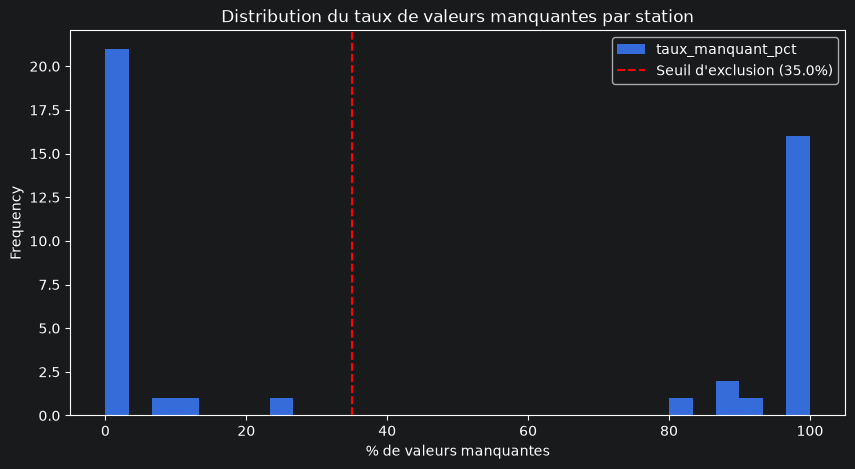

In [7]:
seuil = config.MAX_MISSING_PERCENT
nb_total = len(stations_quality)
nb_exclues = (stations_quality["taux_manquant_pct"] > seuil).sum()
print(f"Sur {nb_total} stations, {nb_exclues} seraient exclues (> {seuil}% de valeurs manquantes).")

stations_quality["taux_manquant_pct"].plot(
    kind="hist", bins=30, title="Distribution du taux de valeurs manquantes par station"
)
plt.axvline(seuil, color="red", linestyle="--", label=f"Seuil d'exclusion ({seuil}%)")
plt.xlabel("% de valeurs manquantes")
plt.legend()
plt.show()


## 5. Référentiel des communes

In [8]:
communes_files = sorted(glob.glob(os.path.join(config.COMMUNES_RAW_DIR, "*.csv.gz")))
print(f"{len(communes_files)} fichier(s) communes trouvé(s) :")
for f in communes_files:
    print(f"  - {os.path.basename(f)}")

assert communes_files, "Aucun fichier communes trouvé. Lancez d'abord src/download_data.py."
communes_path = communes_files[0]

communes = pd.read_csv(communes_path, compression="gzip", dtype={"code_insee": str, "dep_code": str})
print(f"\n{len(communes):,} communes chargées.")
communes.columns.tolist()


1 fichier(s) communes trouvé(s) :
  - communes-france-2025.csv.gz

34,935 communes chargées.


/tmp/ipykernel_52250/487317411.py:9: DtypeWarning: Columns (0: canton_code, 1: epci_code, 2: code_insee_centre_zone_emploi, 3: code_unite_urbaine) have mixed types. Specify dtype option on import or set low_memory=False.
  communes = pd.read_csv(communes_path, compression="gzip", dtype={"code_insee": str, "dep_code": str})


['Unnamed: 0',
 'code_insee',
 'nom_standard',
 'nom_sans_pronom',
 'nom_a',
 'nom_de',
 'nom_sans_accent',
 'nom_standard_majuscule',
 'typecom',
 'typecom_texte',
 'reg_code',
 'reg_nom',
 'dep_code',
 'dep_nom',
 'canton_code',
 'canton_nom',
 'epci_code',
 'epci_nom',
 'academie_code',
 'academie_nom',
 'code_postal',
 'codes_postaux',
 'zone_emploi',
 'code_insee_centre_zone_emploi',
 'code_unite_urbaine',
 'nom_unite_urbaine',
 'taille_unite_urbaine',
 'type_commune_unite_urbaine',
 'statut_commune_unite_urbaine',
 'population',
 'superficie_hectare',
 'superficie_km2',
 'densite',
 'altitude_moyenne',
 'altitude_minimale',
 'altitude_maximale',
 'latitude_mairie',
 'longitude_mairie',
 'latitude_centre',
 'longitude_centre',
 'grille_densite',
 'grille_densite_texte',
 'niveau_equipements_services',
 'niveau_equipements_services_texte',
 'gentile',
 'url_wikipedia',
 'url_villedereve']

In [9]:
# Colonnes de coordonnées attendues (cf. metadata du dataset villedereve.fr)
coord_cols = [c for c in communes.columns if "latitude" in c.lower() or "longitude" in c.lower()]
print("Colonnes de coordonnées disponibles :", coord_cols)
communes[["nom_standard", "dep_code"] + coord_cols].head()


Colonnes de coordonnées disponibles : ['latitude_mairie', 'longitude_mairie', 'latitude_centre', 'longitude_centre']


,nom_standard,dep_code,latitude_mairie,longitude_mairie,latitude_centre,longitude_centre
0,L'Abergement-Clémenciat,01,46.151,4.921,46.153,4.926
1,L'Abergement-de-Varey,01,46.007,5.423,46.009,5.428
2,Ambérieu-en-Bugey,01,45.958,5.360,45.961,5.373
3,Ambérieux-en-Dombes,01,45.996,4.903,45.996,4.912
4,Ambléon,01,45.748,5.601,45.750,5.594


### Communes sans coordonnées GPS


In [10]:
# On utilise les coordonnées du centre si elles existent, sinon la mairie
lat_col = "latitude_centre" if "latitude_centre" in communes.columns else "latitude_mairie"
lon_col = "longitude_centre" if "longitude_centre" in communes.columns else "longitude_mairie"

missing_coords = communes[communes[lat_col].isna() | communes[lon_col].isna()]
print(f"{len(missing_coords):,} communes sans coordonnées sur {len(communes):,} ({100*len(missing_coords)/len(communes):.2f}%).")

print("\nExtrait des communes sans coordonnées :")
missing_coords[["nom_standard", "dep_code"]].head(15)


9 communes sans coordonnées sur 34,935 (0.03%).

Extrait des communes sans coordonnées :


,nom_standard,dep_code
4342,Marseille,13
20117,Culey,55
23101,Les Hauts-Talican,60
27082,Lyon,69
29244,Paris,75
29328,Bihorel,76
29810,Saint-Lucien,76
32700,L'Oie,85
32739,Sainte-Florence,85


In [11]:
# Vérifie que les villes mentionnées dans le sujet du défi sont bien concernées
for nom in config.MISSING_CITIES_LAT_LON:
    match = communes[communes["nom_standard"].str.contains(nom, case=False, na=False)]
    if match.empty:
        print(f"  [?] '{nom}' introuvable dans le référentiel (vérifier l'orthographe)")
    else:
        row = match.iloc[0]
        a_des_coords = pd.notna(row[lat_col]) and pd.notna(row[lon_col])
        statut = "a déjà des coordonnées" if a_des_coords else "SANS coordonnées (à compléter)"
        print(f"  - {nom} -> trouvé ({row['nom_standard']}, dept {row['dep_code']}) : {statut}")


  - Marseille -> trouvé (Marseillette, dept 11) : a déjà des coordonnées
  - Paris -> trouvé (Seyssinet-Pariset, dept 38) : a déjà des coordonnées
  - Culey -> trouvé (Culey-le-Patry, dept 14) : a déjà des coordonnées
  - Les Hauts-Talican -> trouvé (Les Hauts-Talican, dept 60) : SANS coordonnées (à compléter)
  - Lyon -> trouvé (Cognat-Lyonne, dept 03) : a déjà des coordonnées
  - Bihorel -> trouvé (Bihorel, dept 76) : SANS coordonnées (à compléter)
  - Saint-Lucien -> trouvé (Saint-Lucien, dept 28) : a déjà des coordonnées
  - L'Oie -> trouvé (L'Oie, dept 85) : SANS coordonnées (à compléter)
  - Sainte-Florence -> trouvé (Sainte-Florence, dept 33) : a déjà des coordonnées


## 6. Premier calcul de jours de gel — vérification de cohérence

On calcule, pour la station la plus proche d'une grande ville bien connue (ex: la
station qui dessert Paris ou Marseille), le nombre de jours de gel par année sur
2014-2023. On s'attend à un ordre de grandeur raisonnable (quelques jours à quelques
dizaines de jours par an selon la région), ce qui permet de détecter une erreur
grossière (ex: mauvaise unité, mauvais seuil) avant d'aller plus loin.

**Rappel important** : `TN` est exprimée en **°C et 1/10ème de degré** d'après la
documentation Météo-France. On vérifie ci-dessous si les valeurs ont déjà été
converties ou si elles sont encore en dixièmes (ex: -15 pour -1.5°C).


In [12]:
print(df_period["TN"].describe())
print("\nQuelques valeurs de TN en hiver (pour repérer l'unité) :")
hiver = df_period[df_period["AAAAMMJJ"].dt.month.isin([12, 1, 2])]
print(hiver["TN"].sample(min(10, len(hiver)), random_state=0).tolist())


count    73224.000000
mean         6.610684
std          6.468437
min        -19.500000
25%          1.500000
50%          6.600000
75%         11.800000
max         26.100000
Name: TN, dtype: float64

Quelques valeurs de TN en hiver (pour repérer l'unité) :
[2.2, -3.2, nan, 6.4, 7.9, nan, nan, nan, 4.6, -6.0]


**Interprétation** : si les valeurs ressemblent à `-1.5`, `3.2`, `0.0` (échelle
plausible pour des °C), l'unité est déjà en degrés Celsius standards malgré la
mention "1/10" dans la doc (qui décrit la *précision de stockage*, pas forcément
l'unité réellement exposée dans le CSV public — à confirmer empiriquement ici plutôt
que de se fier uniquement à la documentation). Si au contraire les valeurs ressemblent
à `-15`, `32`, `0` sans décimales, il faudra diviser par 10 avant de comparer au seuil
de gel.


Station d'exemple : SAINT JULIEN SUR REYSSOUZE (01367002)

Jours de gel par année :
year
2014    28
2015    59
2016    59
2017    66
2018    44
2019    57
2020    51
2021    57
2022    55
2023    46
Name: is_frost_day, dtype: int64


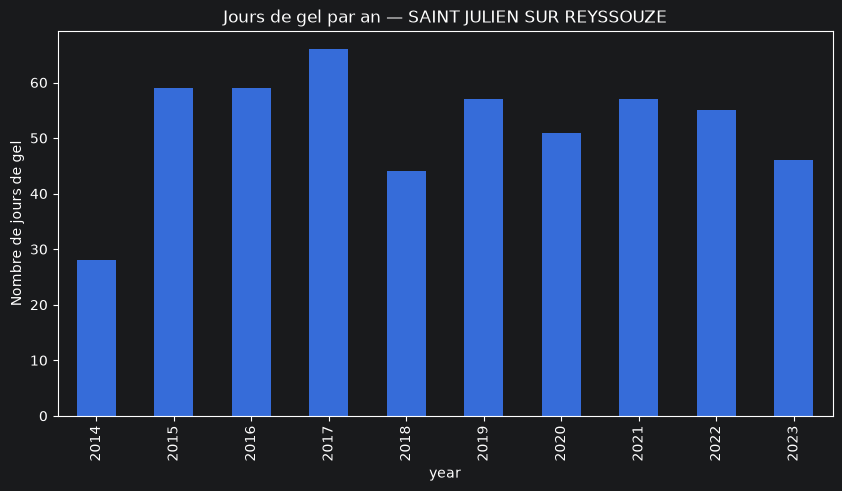

In [13]:
FROST_THRESHOLD = config.FROST_THRESHOLD_C  # 0.0 °C

df_period["is_frost_day"] = df_period["TN"] <= FROST_THRESHOLD
df_period["year"] = df_period["AAAAMMJJ"].dt.year

# On prend la station la plus "complète" du département comme exemple
station_exemple = stations_quality.sort_values("taux_manquant_pct").iloc[0]["NUM_POSTE"]
nom_exemple = stations_quality.sort_values("taux_manquant_pct").iloc[0]["NOM_USUEL"]
print(f"Station d'exemple : {nom_exemple} ({station_exemple})")

frost_par_an = (
    df_period[df_period["NUM_POSTE"] == station_exemple]
    .groupby("year")["is_frost_day"]
    .sum()
)
print("\nJours de gel par année :")
print(frost_par_an)

frost_par_an.plot(kind="bar", title=f"Jours de gel par an — {nom_exemple}")
plt.ylabel("Nombre de jours de gel")
plt.show()


## 7. Matching commune → station la plus proche (test Haversine)

On teste ici la formule de Haversine sur quelques communes connues, en cherchant la
station la plus proche **parmi celles présentes dans le département déjà chargé**
(pour ce test rapide ; le matching définitif devra chercher dans tous les
départements voisins, pas seulement celui de la commune).


In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance à vol d'oiseau (km) entre deux points GPS."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * config.EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


stations_uniques = df_period[["NUM_POSTE", "NOM_USUEL", "LAT", "LON"]].drop_duplicates("NUM_POSTE")

def closest_station(lat_commune, lon_commune, stations_df):
    dists = haversine_km(lat_commune, lon_commune, stations_df["LAT"].values, stations_df["LON"].values)
    idx_min = np.argmin(dists)
    return stations_df.iloc[idx_min], dists[idx_min]

# Exemple : on prend une commune au hasard dans le même département que le fichier chargé
dep_du_fichier = os.path.basename(sample_path).split("_")[1]
commune_test = communes[communes["dep_code"] == dep_du_fichier].dropna(subset=[lat_col, lon_col]).iloc[0]

station_proche, dist_km = closest_station(commune_test[lat_col], commune_test[lon_col], stations_uniques)
print(f"Commune testée : {commune_test['nom_standard']} (dept {dep_du_fichier})")
print(f"Station la plus proche (dans ce département) : {station_proche['NOM_USUEL']} ({station_proche['NUM_POSTE']})")
print(f"Distance à vol d'oiseau : {dist_km:.1f} km")


Commune testée : L'Abergement-Clémenciat (dept 01)
Station la plus proche (dans ce département) : BANEINS (01028001)
Distance à vol d'oiseau : 3.8 km


## Prochaines étapes

- Si l'unité de `TN` s'avère être en dixièmes de degré (à vérifier ci-dessus),
  adapter le seuil de gel en conséquence dans tout le code.
- Étendre le matching commune → stations pour chercher dans **tous** les
  départements (pas seulement celui de la commune), avec un repli sur un nombre de
  stations candidates (`NUM_NEAREST_STATIONS`) avant de retenir la première valide
  après filtrage qualité (35%).
- Construire `geo_matching.py` (KDTree ou Haversine vectorisé) et
  `frost_calculator.py` (lecture à la demande des fichiers, calcul des jours de gel,
  agrégations demandées par le sujet).
